In [1]:
from fontTools.ttLib.tables.TupleVariation import DELTAS_SIZE_MASK

"""
Testing the fb_tools functions for treatment summaries
"""

# standard imports
import os
import geopandas as gpd
import pandas as pd

from pathlib import Path
from os.path import join

# Import fb_tools (!!)
# https://github.com/maxwellCcook/fb_tools
from fb_tools import (
    summarize_treatments, lfps_mosaic, lfps_request,
    build_scenarios, list_files, apply_treatment
)

# directories
# use the current working directory
projdir = Path.cwd().parents[1] # moves up two, outside code directory
boxdir = Path.cwd().parents[3] # moves up two, outside code directory
print(f"Box directory: {boxdir}")
print(f"Project directory set to: {projdir}")
print(os.getcwd())

mdir = join(boxdir,'projects/COSWAP/data/spatial/')

# environ vars
proj_crs = 26913  # NAD83 UTM Zone 13N

print("Ready to go !")

Box directory: \\Mac\Home\Library\CloudStorage\Box-Box\MCC
Project directory set to: \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\code\Python
Ready to go !


In [2]:
# --- Load a treatment file
fp = join(projdir,'data/spatial/raw/treatments/COSWAP/ALL_PROJECTS_merge.shp')
trts = gpd.read_file(fp)

# --- Assume all are mechanical thinning
trts['TRT_TYPE'] = 'Mech Thin'

# --- Add an ID column
trts['TRT_ID'] = trts.index + 1

print(f"Number of treatment units: {len(trts)}\n")
trts.head()

Number of treatment units: 184



,PRJ_NAME,COUNTY,SFA,BNDY_TYPE,ACRES,AGENCY,UNIT_NM,STATUS,geometry,TRT_TYPE,TRT_ID
0,Stanley Park,Jefferson,Upper South Platte RMRI,Planned,71.845322,Denver Mountain Park,NaN,Completed,"POLYGON Z ((475369.779 4384434.591 0, 475610.1...",Mech Thin,1
1,Jerome Miller,Jefferson,Upper South Platte RMRI,Treatment,165.641189,US Forest Service,MG10,Completed,"MULTIPOLYGON Z (((470657.861 4358540.121 0, 47...",Mech Thin,2
2,Dedisse Park,Jefferson,Upper South Platte RMRI,Planned,54.925666,Denver Mountain Parks,NaN,Completed,"POLYGON Z ((470626.052 4386736.416 0, 470756.9...",Mech Thin,3
3,Blue Creek 2,Jefferson,Upper South Platte RMRI,Planned,435.153879,Jefferson Conservation District,NaN,Completed,"POLYGON Z ((470090.455 4379868.512 0, 470153.8...",Mech Thin,4
4,Arnett Ranch Road 2,Jefferson,Upper South Platte RMRI,Planned,109.634271,Jefferson Conservation District,NaN,Completed,"POLYGON Z ((481563.938 4373101.873 0, 481564.8...",Mech Thin,5


In [3]:
# --- Load the strategic focal areas (analysis extents)
fp = join(projdir,'data/spatial/raw/treatments/COSWAP/Strategic_Focus_Areas_COSWAP.shp')
sfas = gpd.read_file(fp)
# --- Keep ones with treatment data
sfas = sfas[sfas['NAME'].isin(trts['SFA'].unique())]
print(sfas.head(len(sfas)))
# --- Dissolve and explode once for unique regions
sfas['dissolve'] = 'Region'
sfas['geometry'] = sfas.geometry.buffer(100)
sfas_d = sfas.dissolve('dissolve', as_index=False).explode(index_parts=False)
print(f"Regions after dissolve/explode: {len(sfas_d)}")

   OBJECTID                     NAME         acres    TYPE  \
0       251                  Boulder  1.916260e+09  County   
1       263                  Douglas  2.180690e+09  County   
2       266                  El Paso  5.511470e+09  County   
5       280                  Larimer  6.816740e+09  County   
6       305                   Teller  1.446630e+09  County   
7         0  Southwest Colorado RMRI  2.918590e+09    RMRI   
8      1024  Upper South Platte RMRI  4.787070e+09    RMRI   
9         0      Upper Arkansas RMRI  3.665640e+09    RMRI   

                                            geometry  
0  MULTIPOLYGON (((495311.967 4423874.526, 495307...  
1  POLYGON ((517933.063 4379891.602, 517938.824 4...  
2  POLYGON ((506056.564 4331184.312, 506592.622 4...  
5  POLYGON ((481271.761 4538602.982, 481304.556 4...  
6  POLYGON ((497101.55 4331182.733, 497134.554 43...  
7  POLYGON ((179567.852 4195470.275, 180336.225 4...  
8  POLYGON ((496140.012 4401411.042, 496188.96 44...  
9

In [4]:
# --- Gather baseline fuelscape for the SFAs
out_dir = join(boxdir,'projects/COSWAP/data/spatial/raw/fuelscapes/baseline/')
out_fp = join(out_dir,"baseline_lcp.tif")

if not os.path.exists(out_fp):
    # --- Option A: Download by region and mosaic
    lcp_da = lfps_mosaic(
        regions_gdf=sfas_d,
        out_dir=out_dir,
        lf_year="2022",
        lodgepole_adjust=True,
        rename="baseline_lcp",
        keep_tiles=False,   # True to keep all files after mosaic
        clip=True # clip to input geometry
    )

    # # --- Option B: One large-extent download and clip to regions (takes longer sometimes?)
    # lcp_da = lfps_request(
    #     region=sfas,
    #     out_dir=out_dir,
    #     lf_year="2022",
    #     lodgepole_adjust=True,
    #     rename="lcp_baseline",
    #     clip=True
    # )
else:
    lcp_da = out_fp

lcp_da

'\\\\Mac\\Home\\Library\\CloudStorage\\Box-Box\\MCC\\projects/COSWAP/data/spatial/raw/fuelscapes/baseline/baseline_lcp.tif'

In [6]:
# --- Run fuel modifications for Mech Thin (apply_treatment module)

out_fp = join(boxdir,'projects/COSWAP/data/spatial/raw/fuelscapes/treated/lcp_MechThin.tif')

# load the canopy and surface modifications tables
canopy  = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/canopy_effects.csv")
surface = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/surface_effects.csv")
print(f"Treatments: {canopy.Treatment.unique()}")

if not os.path.exists(out_fp):
    # --- Landscape-scale (treat every pixel)
    treated = apply_treatment(
        lcp = lcp_da,
        canopy_df = canopy,
        surface_df = surface,
        scenario = {"canopy": "Mech Thin", "surface": "Manage"},
    )

    # --- Save this file out
    os.makedirs(os.path.dirname(out_fp), exist_ok=True)
    treated.rio.to_raster(out_fp)
    print(f"\nSaved to {out_fp}")
else:
    treated = out_fp
treated

Treatments: <StringArray>
[         'Thin',     'Hand Thin',     'Mech Thin',        'RxFire',
 'Complete Hand', 'Complete Mech',     'Masticate',         'Patch',
      'LowSevWF',      'ModSevWF',     'HighSevWF',     'Overstory']
Length: 12, dtype: str


'\\\\Mac\\Home\\Library\\CloudStorage\\Box-Box\\MCC\\projects/COSWAP/data/spatial/raw/fuelscapes/treated/lcp_MechThin.tif'

In [7]:
# # --- Run fire behavior models
#
# mdir = join(boxdir,'projects/COSWAP/data/spatial/')
#
# # --- Manually specify fire scenarios
#
# # --- Paths
# projdir     = Path.cwd().parents[1]
# fm_exe      = list_files(projdir, "TestFlamMap.exe", recursive=True)[0]
# lcp_dir     = join(mdir,"raw/fuelscapes")
# output_root = join(mdir,"mod/flammap/outputs")
#
# # --- 1. Define weather / fuel-moisture conditions (one row per scenario)
# conditions = pd.DataFrame({
#     "Scenario":       ["Pct25", "Pct50", "Pct97"],
#     "WIND_SPEED":     [8, 9, 17],
#     "WIND_DIRECTION": [-1, -1, -1],
#     "FM_1hr":         [21, 12, 5.8],
#     "FM_10hr":        [17, 13, 7.5],
#     "FM_100hr":       [15, 13, 8.5],
#     "FM_1000hr":      [15, 14, 10.5],
#     "FM_herb":        [100, 80, 30],
#     "FM_woody":       [130, 110, 60],
#     "FM_NAME":        ["Pct25", "Pct50", "Pct97"], # file naming
#     "ERC":            [1, 1, 1],
# })
#
# # --- 2. LCP files to pair with every condition (baseline + treatments)
# lcps = list_files(lcp_dir, "*.tif", recursive=True)
# print(lcps)
#
# # --- 3. Build the cross-product table  (5 conditions × N lcps)
# scenarios_df = build_scenarios(
#     conditions, lcps,
#     outputs="FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",
# )
# print(f"{len(scenarios_df)} total runs")
# print(scenarios_df.head())

In [8]:
# # --- Run the FlamMap scenarios
# from fb_tools import run_batch, plot_bands
# import rioxarray as rxr
#
# # --- Run (works with df from either A or B above)
# summary = run_batch(
#     fm_exe=fm_exe,
#     scenarios_df=scenarios_df,
#     output_root=output_root,
#     n_process=3,
#     stack_out=True,    # stacks per-output TIFFs → one multiband file per run
#     cleanup=True,      # removes the single-band TIFFs afterward
#     mask=sfas_d
# )
#
# # --- Check for any failures
# failures = summary[summary["status"] != "success"]
# if not failures.empty:
#     print("Failed runs:")
#     print(failures[["Scenario", "LCP", "status"]])
#
# # # --- Inspect one result
# # row = summary.iloc[0]
# # stacked_tif = list(Path(row["output_dir"]).glob("*.tif"))[0]
# # da = rxr.open_rasterio(stacked_tif, masked=True)
# # fig, axes = plot_bands(da, cols=2)
# # fig.suptitle(f"{Path(row['LCP']).stem} / {row['Scenario']}", y=1.02)

## Suppression Difficulty Index

In [10]:
from fb_tools import fetch_counties, fetch_osm_roads
counties = fetch_counties(trts, state_fips='08')  # or '08' for CO, etc.
roads, trails = fetch_osm_roads(trts, out_crs=26913, chunk_by=counties)

  Found 48 counties
  Querying OSM chunk 1/10 (Douglas)...
    93899 raw features
  Querying OSM chunk 2/10 (Chaffee)...
    6262 raw features
  Querying OSM chunk 3/10 (El Paso)...
    132977 raw features
  Querying OSM chunk 4/10 (Larimer)...
    87516 raw features
  Querying OSM chunk 5/10 (La Plata)...
    9143 raw features
  Querying OSM chunk 6/10 (Boulder)...
    69406 raw features
  Querying OSM chunk 7/10 (Teller)...
    6525 raw features
  Querying OSM chunk 8/10 (Lake)...
    2378 raw features
  Querying OSM chunk 9/10 (Jefferson)...
    97671 raw features
  Querying OSM chunk 10/10 (Montezuma)...
    5593 raw features
OSM: 315788 road segments, 190066 trail segments


In [22]:
from fb_tools import calculate_sdi, calculate_delta_sdi, stacked_output_path

output_root = join(mdir,"mod/flammap/outputs/baseline")
lcp_da = join(mdir,"raw/fuelscapes/baseline/baseline_lcp.tif")
fm_stack = Path(join(mdir,"mod/flammap/outputs/baseline_lcp/Pct97/Pct97_BASELINE_LCP.tif"))
fm_stack_tr = Path(join(mdir,"mod/flammap/outputs/lcp_MechThin/Pct97/Pct97_LCP_MECHTHIN.tif"))
print(fm_stack)

# load the RTC lookup table for the Western US
rtc_fp = os.path.join(projdir,'code/dev/SDI/08_RTC_lookup_SDIwt_westernUS_2021_update.txt')

# output directory
sdi_dir = os.path.join(mdir,'mod/sdi')
os.makedirs(sdi_dir, exist_ok=True)

# # --- Baseline SDI
# sdi_base = calculate_sdi(
#     lcp=lcp_da,
#     flammap_stack=fm_stack,
#     roads_gdf=roads,
#     trails_gdf=trails,
#     rtc_path=rtc_fp,
#     out_path=join(sdi_dir,"SDI97_BASELINE.tif")
# )

# --- Calculate the treated SDI
sdi_treated = calculate_sdi(
    lcp=treated,
    flammap_stack=fm_stack_tr,
    roads_gdf=roads,
    trails_gdf=trails,
    rtc_path=rtc_fp,
    out_path=join(sdi_dir,"SDI97_MECHTHIN.tif")
)

# # --- Calculate the delta SDI
# delta_sdi = calculate_delta_sdi(
#     sdi_base, sdi_treated,
#     out_path=os.path.join(sdi_dir,f"deltaSDI97_MECHTHIN.tif"),
# )

\\Mac\Home\Library\CloudStorage\Box-Box\MCC\projects\COSWAP\data\spatial\mod\flammap\outputs\baseline_lcp\Pct97\Pct97_BASELINE_LCP.tif
Computing road distance...
Computing trail density...
Computing sub-indices...
Assembling final SDI...
SDI saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\projects\COSWAP\data\spatial\mod\sdi\SDI97_MECHTHIN.tif


## Treatment summary

In [36]:
# --- Summarize FLAMELENGTH and CROWNSTATE within treatment units
results = summarize_treatments(
    trts,
    id_col='TRT_ID',
    type_col='TRT_TYPE',
    baseline_dir=join(mdir,'mod/flammap/outputs/baseline_lcp/'),
    treated_dirs={
        'Mech Thin': join(mdir,'mod/flammap/outputs/lcp_MechThin/'),
    },
    percentiles=("Pct25", "Pct97"),
    baseline_sdi=join(sdi_dir,"SDI97_BASELINE.tif"),
    treated_sdi={'Mech Thin': join(sdi_dir,"SDI97_MECHTHIN.tif")},
    out_dir=join(mdir,'mod/outputs/summaries'),
)

  Processing percentile: Pct25
    Building zone grid for all treatment polygons...
    Building zone grid for treatment type: 'Mech Thin'...
  Processing percentile: Pct97
  Computing SDI zonal statistics...
Results saved to \\Mac\Home\Library\CloudStorage\Box-Box\MCC\projects\COSWAP\data\spatial\mod\outputs\summaries


In [24]:
results['fl'].head()

,TRT_ID,TRT_TYPE,ACRES_GIS,percentile,scenario,FL_class,FL_bl_count,FL_bl_pct,FL_tr_count,FL_tr_pct,delta_pct
0,1,Mech Thin,71.901963,Pct25,mech_thin,0-2ft,69.0,21.428571,67.0,20.807453,-0.621118
1,1,Mech Thin,71.901963,Pct25,mech_thin,2-4ft,170.0,52.795031,179.0,55.590062,2.795031
2,1,Mech Thin,71.901963,Pct25,mech_thin,4-8ft,11.0,3.416149,4.0,1.242236,-2.173913
3,1,Mech Thin,71.901963,Pct25,mech_thin,0,72.0,22.360248,72.0,22.360248,0.000000
4,2,Mech Thin,165.770561,Pct25,mech_thin,0-2ft,378.0,50.738255,364.0,48.859060,-1.879195


In [25]:
results['cs'].head()

,TRT_ID,TRT_TYPE,ACRES_GIS,percentile,scenario,CS_class,CS_bl_count,CS_bl_pct,CS_tr_count,CS_tr_pct,delta_pct
0,1,Mech Thin,71.901963,Pct25,mech_thin,NonBurnable,72.0,22.360248,72.0,22.360248,0.000000
1,1,Mech Thin,71.901963,Pct25,mech_thin,Passive Crown,215.0,66.770186,210.0,65.217391,-1.552795
2,1,Mech Thin,71.901963,Pct25,mech_thin,Surface,35.0,10.869565,40.0,12.422360,1.552795
3,2,Mech Thin,165.770561,Pct25,mech_thin,NonBurnable,46.0,6.174497,46.0,6.174497,0.000000
4,2,Mech Thin,165.770561,Pct25,mech_thin,Passive Crown,390.0,52.348993,422.0,56.644295,4.295302


In [37]:
results['sdi'].head()

,TRT_ID,TRT_TYPE,ACRES_GIS,scenario,SDI_bl_mean,SDI_tr_mean,SDI_delta_mean
0,1,Mech Thin,71.901963,mech_thin,0.647081,0.628851,0.018230
1,2,Mech Thin,165.770561,mech_thin,0.576940,0.559423,0.017517
2,3,Mech Thin,54.968631,mech_thin,0.651008,0.636008,0.015000
3,4,Mech Thin,435.493773,mech_thin,0.529091,0.518100,0.010991
4,5,Mech Thin,109.721341,mech_thin,0.512322,0.497088,0.015234


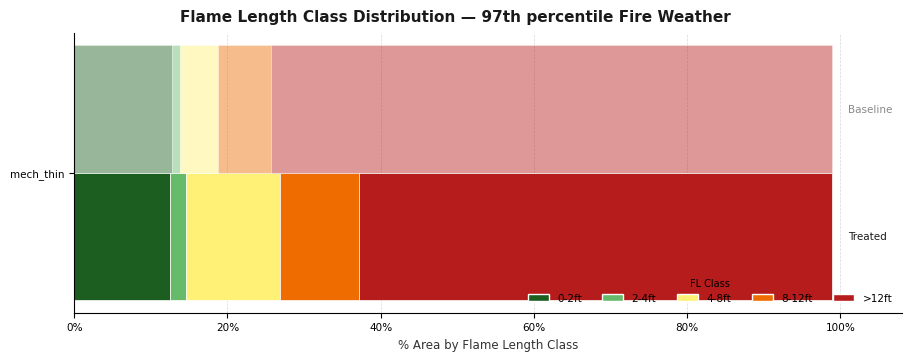

In [28]:
from fb_tools import (plot_fl_stackedbar, plot_fl_delta_bar,
                      plot_cs_stackedbar_multipct, plot_sdi_boxplot)
fig, ax = plot_fl_stackedbar(results['fl'], percentile='Pct97')

  Saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\projects/COSWAP/data/spatial/CS_stacked_25_97.png


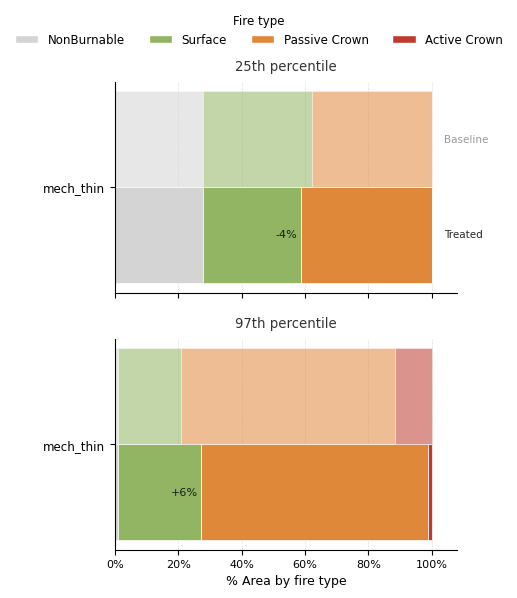

In [29]:
fig, axes = plot_cs_stackedbar_multipct(results['cs'], save_path=join(mdir,'CS_stacked_25_97.png'))

  Saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\projects/COSWAP/data/spatial/FL_stacked_25_97.png


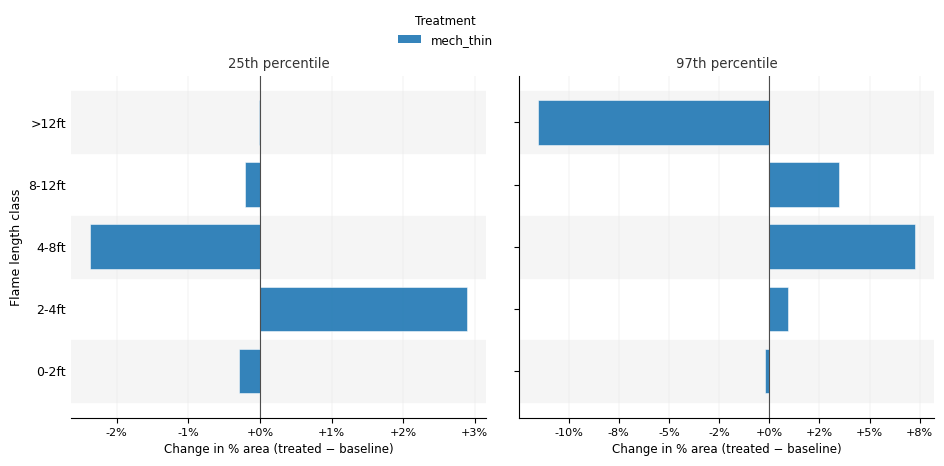

In [30]:
fig, axes = plot_fl_delta_bar(results['fl'], percentiles=('Pct25','Pct97'), save_path=join(mdir,'FL_stacked_25_97.png'))

  Saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\projects/COSWAP/data/spatial/SDI97_box.png


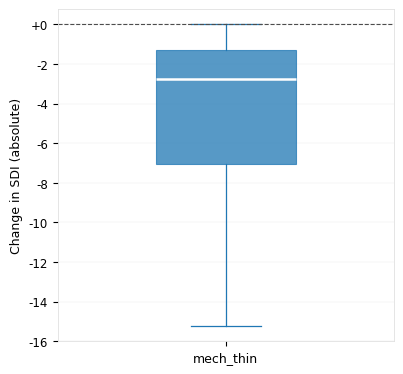

In [41]:
# --- Calculate the percent change
results['sdi']['pct_change'] = (100 * results['sdi']['SDI_delta_mean'] / results['sdi']['SDI_bl_mean']) * -1
fig, ax = plot_sdi_boxplot(results['sdi'], y_col='pct_change', save_path=join(mdir,'SDI97_box.png'))